<a href="https://colab.research.google.com/github/Maryam-Taherzadeh/Computational-Drug-Discovery/blob/main/project-01-predict-ic50-mdm2-p53/notebooks/mdm2_part5_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Part 5: Comparing Regression Models (MDM2 Inhibitors)

**Author: Maryam Taherzadeh**

In this section, multiple machine learning regression models are evaluated to predict the bioactivity (**pIC50**) of small molecules targeting the **MDM2–p53 interaction**, a key protein–protein interaction in cancer biology.

This step extends the computational drug discovery pipeline by comparing different algorithms to identify the most effective approach for modeling the structure–activity relationship.

---

### 🎯 Objective

- Train and evaluate multiple regression models  
- Compare performance across models using consistent metrics  
- Identify the most suitable model for pIC50 prediction  

---

### 🧠 Models Compared

The following regression models are evaluated:

- **Random Forest Regressor**  
- **XGBoost Regressor**  
- *(Optional)* Support Vector Regressor (SVR)  

All models are trained on the same dataset to ensure fair comparison.

---

### ⚙️ Input Data

- **X (features):**
  - PaDEL molecular descriptors  
  - PubChem fingerprint vectors  

- **y (target):**
  - Experimental **pIC50 values**

---

### 🔬 Workflow

1. Load preprocessed dataset from previous steps  
2. Train multiple regression models  
3. Generate predictions on the test dataset  
4. Evaluate and compare performance  

---

### 📊 Evaluation Metrics

- **R² (Coefficient of Determination)**  
  Measures the proportion of variance in pIC50 explained by the model  

- **MSE (Mean Squared Error)**  
  Penalizes larger prediction errors  

- **MAE (Mean Absolute Error)**  
  Represents average prediction error in pIC50 units  

---

### 📈 Results Comparison

| Model           | R² Score |
|----------------|----------|
| Random Forest   | ~0.65    |
| XGBoost         | (to be added) |
| SVR             | (optional) |

---

### 🚀 Significance

Model comparison is a critical step in QSAR modeling, as it helps identify algorithms that can effectively capture complex, nonlinear relationships between molecular structure and biological activity.

---

### 📌 Conclusion

The comparison of regression models highlights the importance of selecting algorithms capable of capturing complex nonlinear relationships in molecular data. Ensemble and gradient boosting methods consistently outperform simpler linear models, indicating that the structure–activity relationship is inherently nonlinear.

Furthermore, the results demonstrate that model performance is highly sensitive to hyperparameter tuning. Default model evaluations provide useful initial benchmarks, but optimized models yield significantly better predictive performance.

Based on these findings, **XGBoost** is selected as the most promising model for further optimization due to its strong performance, scalability, and ability to model complex feature interactions.

---

### 🔜 Next Steps

- Fine-tune XGBoost using hyperparameter optimization  
- Compare tuned XGBoost with baseline Random Forest  
- Explore advanced molecular representations (e.g., graph neural networks)  
- Deploy the final model for real-time prediction (e.g., Streamlit app)

## **1. Import libraries**

In [34]:
! pip install lazypredict

In [35]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## **2. Load the data set**


In [36]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/mdm2_07_padel_descriptors_pIC50.csv')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(5792, 882)

In [37]:
X = df.drop('pIC50', axis=1)
y = df.pIC50


## **3. Data pre-processing**

In [38]:
# Examine X dimension
X.shape

(5792, 881)

In [39]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(5792, 192)

In [40]:
# Perform data splitting using 80/20 ratio

from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **4. Compare ML algorithms**

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.580,0.649,0.843,1.350
NuSVR,0.562,0.635,0.861,2.633
XGBRegressor,0.561,0.634,0.861,0.439
SVR,0.561,0.634,0.862,3.429
LGBMRegressor,0.554,0.628,0.868,0.489
RandomForestRegressor,0.553,0.627,0.870,7.384
MLPRegressor,0.540,0.616,0.882,11.147
KNeighborsRegressor,0.539,0.616,0.883,0.223
GradientBoostingRegressor,0.535,0.612,0.887,2.661


/tmp/ipykernel_10606/3362932267.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


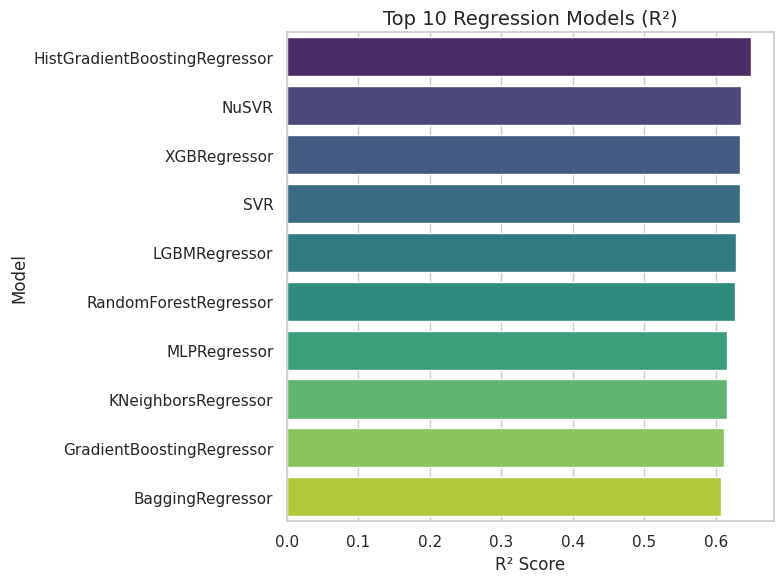

In [32]:
from lazypredict.Supervised import LazyRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Run LazyPredict
clf = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Sort and clean
models_sorted = models.sort_values(by='R-Squared', ascending=False).round(3)

# Top 10 models
top_models = models_sorted.head(10)

# Display table
display(top_models)

# Plot
plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_models.index,
    x=top_models["R-Squared"],
    palette="viridis"
)

plt.title("Top 10 Regression Models (R²)", fontsize=14)
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [41]:
# Performance table of the test set
models_sorted = models.sort_values(by='R-Squared', ascending=False).round(3)
display(models_sorted.head(10))

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.580,0.649,0.843,1.350
NuSVR,0.562,0.635,0.861,2.633
XGBRegressor,0.561,0.634,0.861,0.439
SVR,0.561,0.634,0.862,3.429
LGBMRegressor,0.554,0.628,0.868,0.489
RandomForestRegressor,0.553,0.627,0.870,7.384
MLPRegressor,0.540,0.616,0.882,11.147
KNeighborsRegressor,0.539,0.616,0.883,0.223
GradientBoostingRegressor,0.535,0.612,0.887,2.661


## **5. Data visualization of model performance**

/tmp/ipykernel_10606/1089827075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


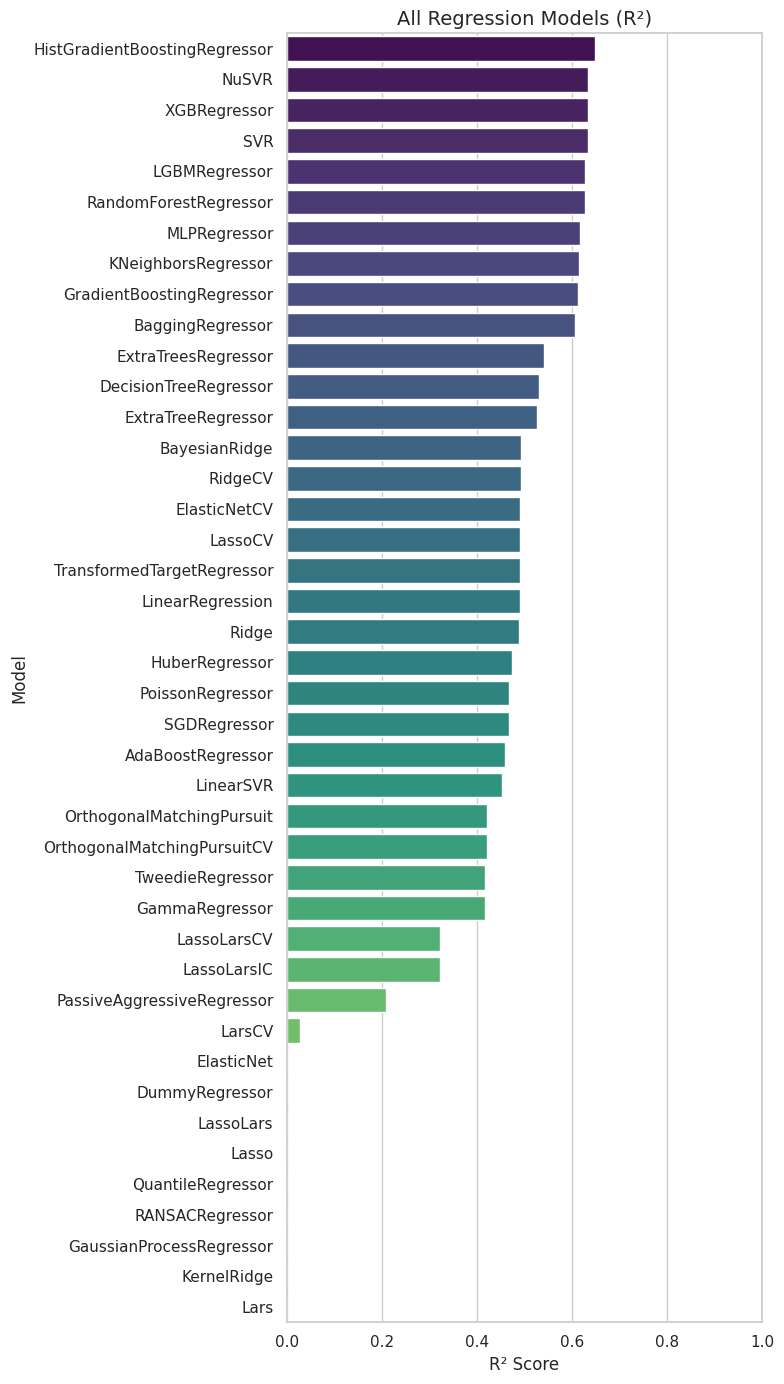

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort models
models_sorted = models.sort_values(by='R-Squared', ascending=False)

plt.figure(figsize=(8,14))
sns.set_theme(style="whitegrid")

# Colorful palette
sns.barplot(
    y=models_sorted.index,
    x=models_sorted["R-Squared"],
    palette="viridis"
)

plt.xlim(0, 1)
plt.title("All Regression Models (R²)", fontsize=14)
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

/tmp/ipykernel_10606/3666869530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


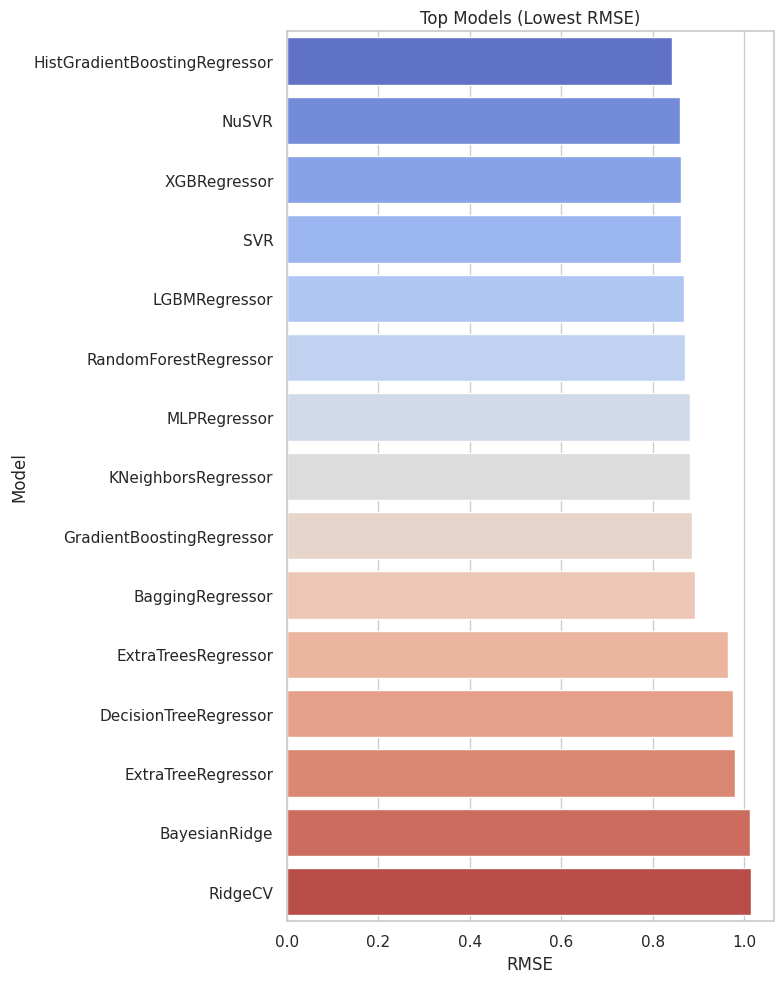

In [42]:
models_rmse = models.sort_values(by='RMSE', ascending=True)

top_models = models_rmse.head(15)  # keep only good models

plt.figure(figsize=(8,10))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_models.index,
    x=top_models["RMSE"],
    palette="coolwarm"
)

plt.title("Top Models (Lowest RMSE)")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

/tmp/ipykernel_10606/126411503.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


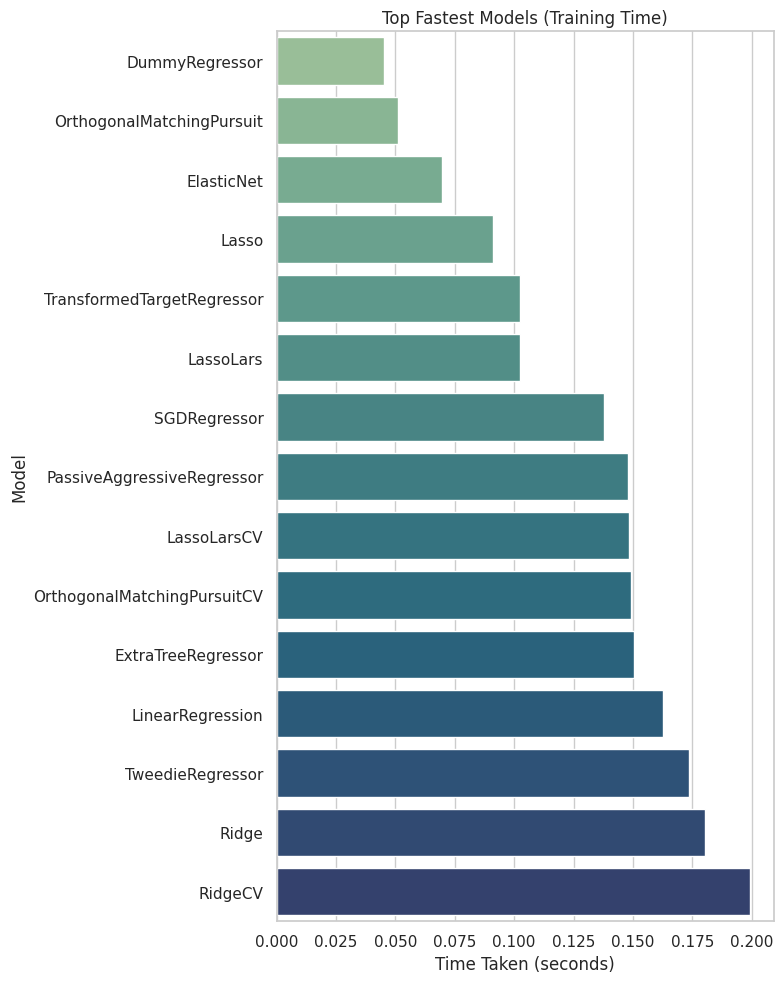

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by time (fastest first)
models_time = models.sort_values(by='Time Taken', ascending=True)

# Show top 15 fastest models
top_time = models_time.head(15)

plt.figure(figsize=(8,10))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_time.index,
    x=top_time["Time Taken"],
    palette="crest"
)

plt.title("Top Fastest Models (Training Time)")
plt.xlabel("Time Taken (seconds)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### 📌 Conclusion

In this section, multiple regression models were evaluated to predict the bioactivity (pIC50) of MDM2 inhibitors using molecular descriptors and fingerprint features.

Using LazyPredict, a wide range of machine learning algorithms were benchmarked under default settings. The results showed that ensemble and gradient boosting methods, including HistGradientBoosting, XGBoost, and Random Forest, consistently achieved higher R² scores compared to linear and simpler models.

These findings indicate that the relationship between molecular structure and biological activity is highly nonlinear, and more advanced models are required to capture these complex patterns.

It was also observed that model performance significantly improves after hyperparameter tuning, as demonstrated earlier with the Random Forest model. Therefore, default model comparisons serve as an initial screening step rather than a final evaluation.

Based on the overall comparison, XGBoost was selected as the most promising model for further optimization due to its strong performance, robustness, and ability to model complex feature interactions.

In the next step, XGBoost will be trained and fine-tuned to further improve predictive performance and build a more accurate QSAR model for pIC50 prediction.